In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")

print(datadir)

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 0.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 1.0

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

In [4]:
coords = [[1.6, 0.0], [1.7, 0.1]] #1st: multistable     // 2nd: unistable synchronized

data_0_L1, data_1_L1, data_2_L1 = dict(), dict(), dict()
data_0_L1["coordinates"] = coords[0]
data_1_L1["coordinates"] = coords[0]
data_2_L1["coordinates"] = coords[1]
lng = int(4*1e3)

for d in [data_0_L1, data_1_L1, data_2_L1]:
    d["weights"] = np.zeros((100))
    d["control"] = [None] * len(data_0_L1["weights"])
    d["state"] = [None] * len(data_0_L1["weights"])
    d["init_state"] = None
    d["energy_input"] = np.zeros((len(d["weights"])))
    d["sync_cost"] = np.zeros((len(d["weights"])))
    d["state_uncontrolled"] = np.zeros((N,2,lng))

data_1_L1["weights"] *= -1

In [5]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def plot_control(c, s, dur, dt, fat=[], filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(32,8), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    for n in range(N):
        if n in fat:
            ax[0].plot(time_array, s[n,0,:], linewidth=4)
        else:
            ax[0].plot(time_array, s[n,0,:])
        ax[1].plot(time_array, c[n,:])

    ax[0].set_xlim(0, dur)

    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

def get_results(d, wi, mc):
    d["control"][wi] = mc.control.copy()
    d["state"][wi] = mc.get_xs()
    d["energy_input"][wi] = cost_functions.control_strength_cost(mc.control, weights, dt)
    d["sync_cost"][wi] = (mc.compute_total_cost() - d["energy_input"][wi])/d["weights"][wi]

def dump_data():
    with open(os.path.join(datadir, 'wb_L1_all_1.pickle'), 'wb') as f:
        pickle.dump(data_1_L1, f)

controlmat = np.ones((N))
costmat = np.ones((N))

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,101,1)
dt = 0.1

------------------- seed =  1


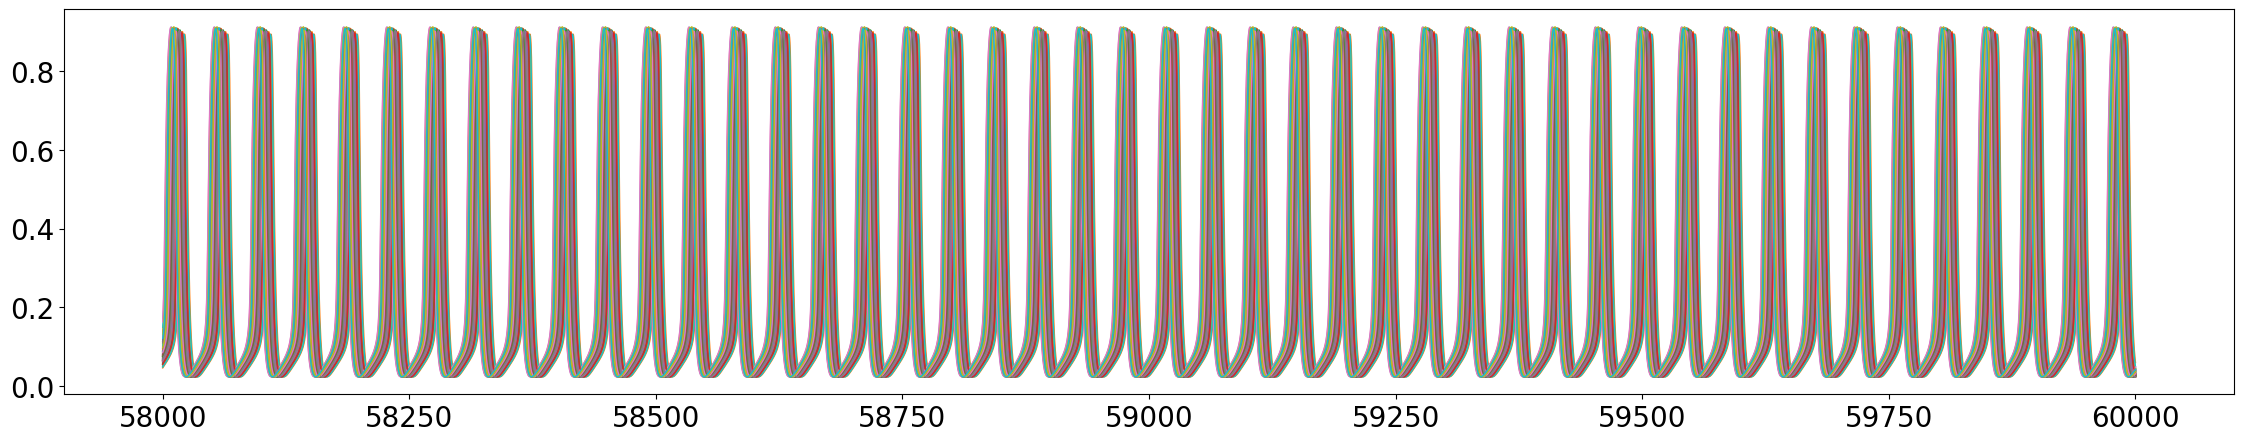

/home/lena/Promotion/neurolib/neurolib/control/optimal_control/cost_functions.py:335: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'getmean_vt'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", line 314:
@numba.njit
def getmean_vt(
^

  xmean = getmean_vt(x_sim, interval)
/home/lena/.local/lib/python3.10/site-packages/numba/core/ir_utils.py:2149: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'var_cost'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", lin

0.032164549250778954


/home/lena/.local/lib/python3.10/site-packages/numba/core/ir_utils.py:2149: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'cc_cost'.

For more information visit https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "neurolib/control/optimal_control/cost_functions.py", line 414:
@numba.njit
def cc_cost(
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))


-0.6242257109598518
------------------- seed =  25


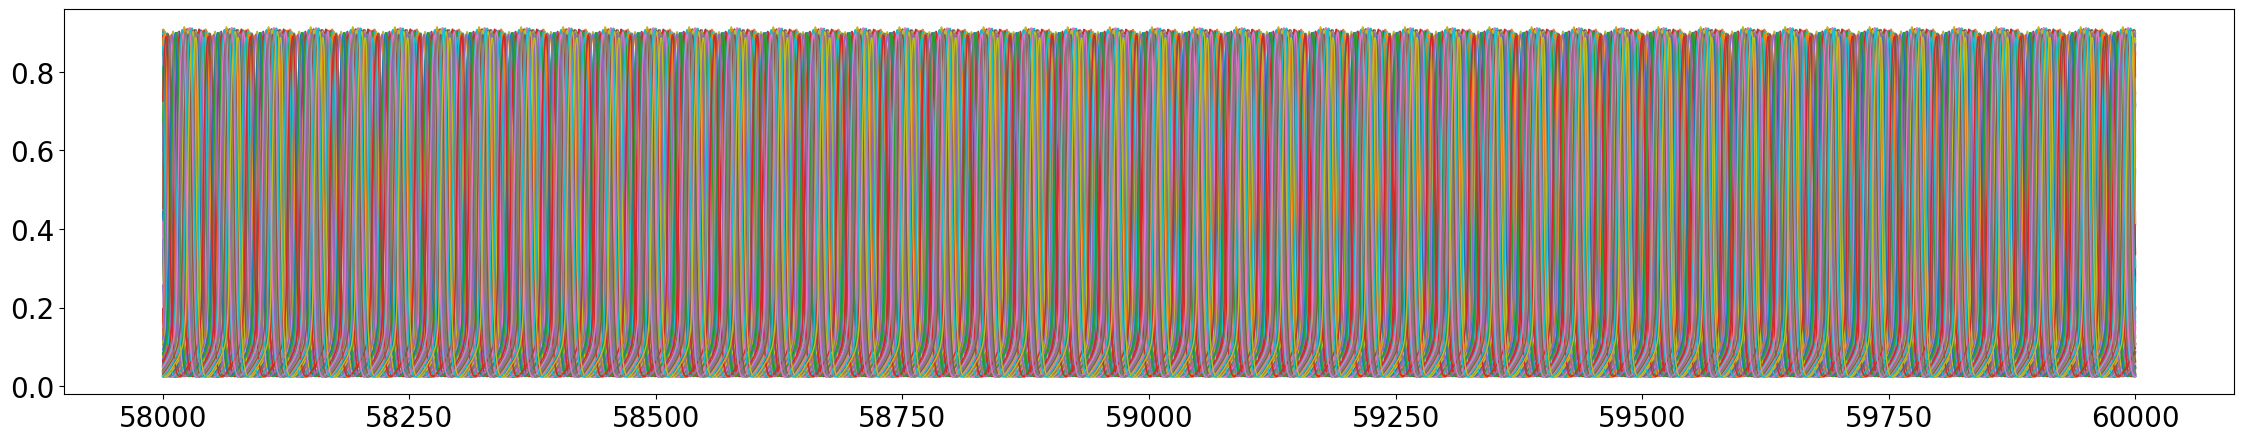

0.08426829728692982
-0.025985539150927384


In [13]:
point = 0
seed = [1, 25]

#for s in np.arange(0,50,1):
for i_s, s in enumerate(seed):

    print("------------------- seed = ", s)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=s)
    testd = 60.*1e3     # needs to stay 60!!!!!
    dt = model.params.dt
    model.params.duration = testd
    model.params.seed = s
    setparams(model)

    #zero_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    #input = zero_input.copy()
    #input[0,int(0.*1e3/dt):int(5.*1e3/dt)] = 1.

    #print(model.params.exc_init[0,0])

    model.params.exc_ext_baseline = data_0_L1["coordinates"][0]
    model.params.exc_inh_baseline = data_0_L1["coordinates"][1]

    #model.params.exc_ext = input
    model.run()

    plt.figure(figsize=(28,5))

    for n in range(N):
        plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
    plt.show()

    nmaxdelay = model.getMaxDelay()
    einit = np.zeros((N, nmaxdelay+1))
    iinit = np.zeros((N, nmaxdelay+1))

    state = np.zeros((N,2,lng))

    for n in range(N):
        einit[n,:] = model.exc[n,-nmaxdelay-1:]
        iinit[n,:] = model.inh[n,-nmaxdelay-1:]
        state[n,0,:] = model.exc[n, -lng:]

    if i_s == 0:
        data_0_L1["init_state"] = [einit, iinit]
        data_0_L1["state_uncontrolled"] = state.copy()
    else:
        data_1_L1["init_state"] = [einit, iinit]
        data_1_L1["state_uncontrolled"] = state.copy()

    var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(var_cost_asyn)

    cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(cc_cost)

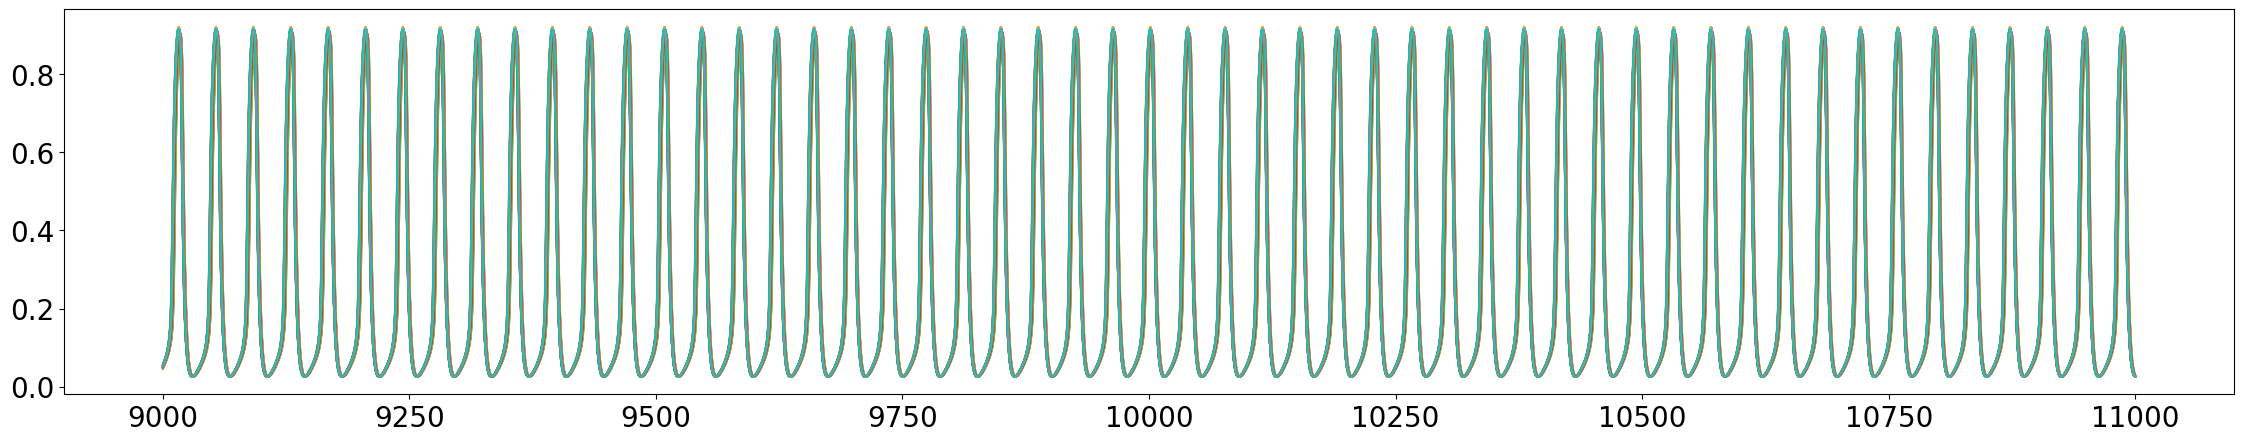

0.002332105821483664
-0.9775374609292389


In [14]:
model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
testd = 11.*1e3   ## needs to stay 11
dt = model.params.dt
model.params.duration = testd
setparams(model)

model.params.exc_ext_baseline = data_2_L1["coordinates"][0]
model.params.exc_inh_baseline = data_2_L1["coordinates"][1]

#model.params.exc_ext = input
model.run()

plt.figure(figsize=(28,5))

for n in range(N):
    plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
plt.show()

nmaxdelay = model.getMaxDelay()
einit = np.zeros((N, nmaxdelay+1))
iinit = np.zeros((N, nmaxdelay+1))

state = np.zeros((N,2,lng))

for n in range(N):
    einit[n,:] = model.exc[n,-nmaxdelay-1:]
    iinit[n,:] = model.inh[n,-nmaxdelay-1:]
    state[n,0,:] = model.exc[n, -lng:]

data_2_L1["init_state"] = [einit, iinit]
data_2_L1["state_uncontrolled"] = state.copy()

var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(var_cost_asyn)

cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(cc_cost)

In [6]:
with open(os.path.join(datadir, 'wb_L1_all_1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data_1_L1 = data_read

In [8]:
print(data_1_L1["weights"])

[ 100.  150.  200.  250.  300.  350.  400.  450.  500.  550.  600.  650.
  700.  750.  800.  850.  900.  950. 1000. 1050. 1100. 1150. 1200. 1250.
 1300. 1350. 1400. 1450. 1500. 1550. 1600. 1650. 1700. 1750. 1800. 1850.
 1900. 1950. 2000. 2050. 2100. 2150. 2200. 2250. 2300. 2350. 2400. 2450.
 2500. 2550. 2600. 2650. 2700. 2750. 2800. 2850. 2900. 2950. 3000. 3050.
 3100. 3150. 3200. 3250. 3300. 3350. 3400. 3450. 3500. 3550. 3600. 3650.
 3700. 3750. 3800. 3850. 3900. 3950. 4000. 4050. 4100. 4150. 4200. 4250.
 4300. 4350. 4400. 4450. 4500. 4550. 4600. 4650. 4700. 4750. 4800. 4850.
 4900. 4950. 5000. 5050.]


In [8]:
data_1_L1["weights"][0] = 100.
for n in range(N-1):
    data_1_L1["weights"][n+1] = data_1_L1["weights"][n] + 50.

In [7]:
def optimize_model(model, step_exp_array, wi, it):
    for k in step_exp_array:
        model.zero_step_encountered = False
        model.step = 10.**(k)
        model.optimize(it)

        get_results(d, wi, model)
        dump_data()

In [8]:
convergence = np.zeros((100))

In [27]:
for wi in range(100):
    if wi not in range(2,16):
        d["control"][wi] = None

------------------------------------------------------------ wi =  2 200.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 16.944984611257862
Final cost : 16.944984611257862
Compute control for a deterministic system
Cost in iteration 0: 16.944984611257862
Final cost : 16.944984611257862
max node ind, input nodes =  54 0


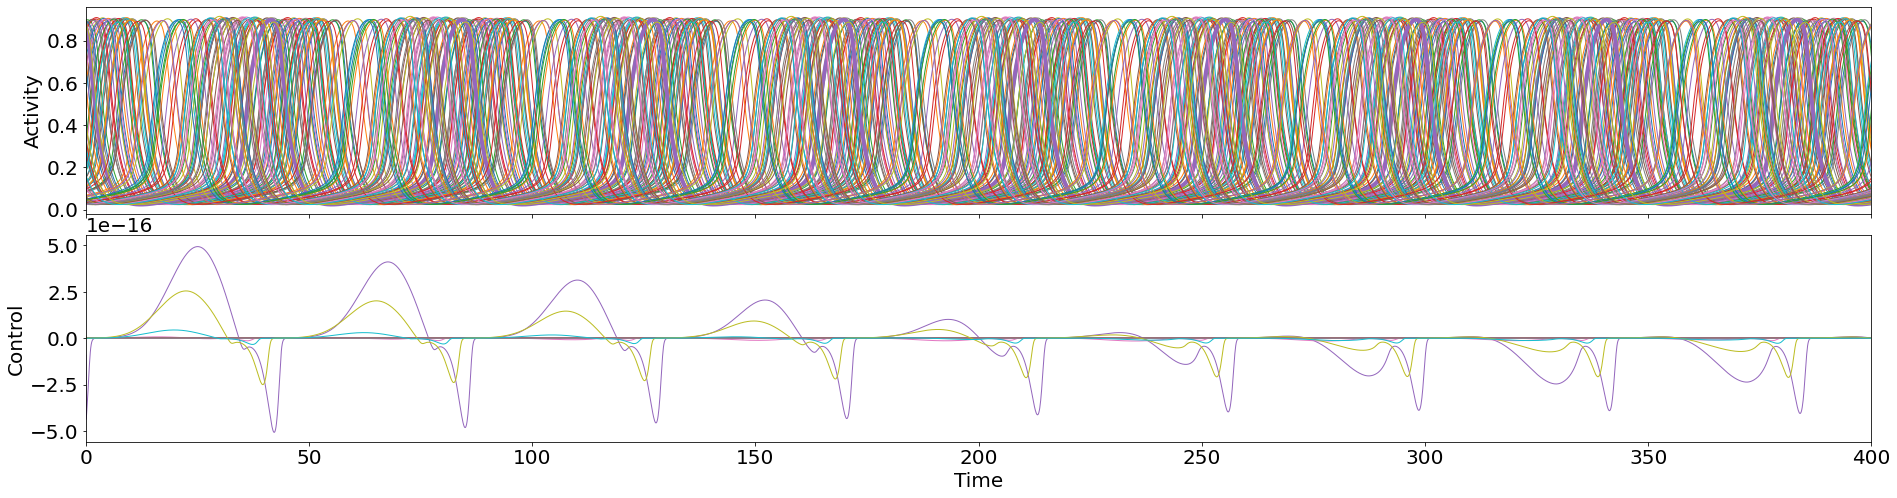

------------------------------------------------------------ wi =  3 250.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 21.181230764072307
Final cost : 21.181230764072307
Compute control for a deterministic system
Cost in iteration 0: 21.156631370516713
Final cost : 21.156631370516713
Compute control for a deterministic system
Cost in iteration 0: 21.156631370516713
Cost in iteration 1: 21.1566313704659
Cost in iteration 2: 21.156631370465895
Cost in iteration 3: 21.156631370465895
Cost in iteration 4: 21.156631370465895
Cost in iteration 5: 21.156631370465895
Cost in iteration 6: 21.156631370465895
Converged in iteration 6 with cost 21.156631370465895
Final cost : 21.156631370465895
Compute control for a deterministic system
Cost in iteration 0: 21.156631370465895
Cost in iteration 1: 21.15663137046589
Cost in iteration 2: 21.15663137046589
Cost in iteration 3: 21.15663137046589
Converged in iteration 3 with cost 21.156

In [ ]:
it = 6
d = data_1_L1
n_input_list = []

for wi in range(2,16):
    print("------------------------------------------------------------ wi = ", wi, d["weights"][wi])

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  d["coordinates"][0]
    model.params["inh_ext_baseline"] =  d["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_var"] = d["weights"][wi]
    model_controlled.maximum_control_strength = max_cntrl
    
    model_controlled.optimize(0)
    
    if type(d["control"][wi]) != type(None):
        if d["control"][wi].ndim == 2:
            model_controlled.control = d["control"][wi].copy()
            model_controlled.update_input()

    model_controlled.channelwise_optimization = True
    model_controlled.optimize(0)
    
    cost0 = model_controlled.compute_total_cost()
    
    if convergence[wi] == 0:

        for j in range(10):
            model_controlled.grad_method = 0
            optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)
            #model_controlled.grad_method = 1
            #optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)

            cost1 = model_controlled.compute_total_cost()
            if np.abs(cost1 - cost0) < 1e-12:
                convergence[wi] = 1
                break
                
            cost0 = model_controlled.compute_total_cost()

    maxnodeind = np.argmax(np.sum(d["control"][wi]**2, axis=1))
    n_input = 0
    for n in range(N):
        if np.sum(d["control"][wi][n,:]**2) > 1e-1:
            n_input += 1
    n_input_list.append(n_input)
    
    print("max node ind, input nodes = ", maxnodeind, n_input)
    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, fat=[maxnodeind], filename=None, title=None)

In [28]:
print(n_input_list)

[0, 1, 9, 3, 4, 4, 3, 3, 5, 9, 15, 17, 18, 22]


In [24]:
print(n_input_list)

[0, 1, 9, 3, 4, 4, 3, 3, 5, 9, 15, 17, 18, 22]
